# Trabajo Práctico 3 - Computer Vision 1

## Nicolás Granato

**Objetivo:** encontrar el logo de Coca-Cola en las imágenes de images usando el template.

El template es una etiqueta plana de Coca-Cola y no coincide con las imágenes en escala, resolución ni forma. Sobre las botellas el logo se curva, y cerca del borde se comprime a lo ancho (según busqué, se llama escorzo). Un matching de intensidad rígido no soporta esto, así que el pipeline se apoya en bordes y en probar el template a muchas escalas y varios anchos.

En orden:

1. Genero candidatos con `cv2.matchTemplate` (correlación normalizada, `TM_CCOEFF_NORMED`), probando el template a muchas escalas y a tres anchos distintos (para el escorzo). Uso dos canales en paralelo: grises (con dos polaridades) y bordes de Canny.
2. Valido cada candidato con chamfer distance (qué tan bien encajan los contornos), HOG (estructura del trazo) y LBP (textura).
3. Filtro por color: el logo va sobre etiqueta roja o sobre fondo blanco, nada más, y lo uso para filtrar.
4. Junto todo en un score de confianza de 0 a 1 y decido con un umbral.

Sobre eso se arman el punto 1 (una detección por imagen), el punto 2 (todas las de la góndola) y el punto 3 (generalizar a todas).

In [1]:
import os, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMAGES_DIR   = "images"
TEMPLATE_DIR = "template"

plt.rcParams['figure.dpi'] = 110

def show_bgr(img, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    if img.ndim == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    return ax

## Carga del template y de las imágenes

Dos cosas antes de usar el template
1. Recortar el margen blanco
El template viene con borde blanco. Como matchTemplate compara todo el rectángulo, ese borde sin información pesa igual que el logo y baja la correlación.

2. Doble polaridad
El template es rojo sobre blanco (en grises: trazo oscuro sobre fondo claro), pero en las botellas el logo es blanco sobre rojo (al revés). Como TM_CCOEFF_NORMED resta la media, un patrón invertido da correlación negativa y el match falla aunque el logo esté ahí. Entonces comparo con el template y con su negativo (255 − T), y me quedo con el que mejor da

Template: pattern.png -> 376x120 px (recortado)
Imagenes (7): ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']


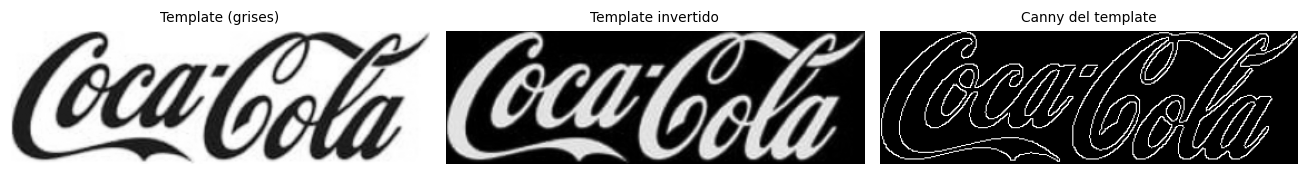

In [2]:
def trim_white(bgr, thr=245):
    #Recorta los márgenes blancos del template
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray < thr)
    if len(xs) == 0:
        return bgr
    return bgr[ys.min():ys.max()+1, xs.min():xs.max()+1]

tpl_path = sorted(glob.glob(os.path.join(TEMPLATE_DIR, "*")))[0]
TPL_BGR  = trim_white(cv2.imread(tpl_path))
TPL_GRAY = cv2.cvtColor(TPL_BGR, cv2.COLOR_BGR2GRAY)

# Diccionario de templates: polaridad normal e invertida
TPLS = {"normal": TPL_GRAY, "invertido": 255 - TPL_GRAY}

img_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*")))
print(f"Template: {os.path.basename(tpl_path)} -> {TPL_GRAY.shape[1]}x{TPL_GRAY.shape[0]} px (recortado)")
print(f"Imagenes ({len(img_paths)}):", [os.path.basename(p) for p in img_paths])

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
show_bgr(TPLS["normal"],   "Template (grises)",   axs[0])
show_bgr(TPLS["invertido"],"Template invertido",  axs[1])
show_bgr(cv2.Canny(TPL_GRAY, 50, 150), "Canny del template", axs[2])
plt.tight_layout(); plt.show()

### Problema: El template es plano, el logo está curvado

El template es una etiqueta plana. En una botella la etiqueta envuelve la superficie: el logo se ve de frente en el centro y se va comprimiendo a lo ancho hacia el borde. El alto queda igual, el ancho se acorta.

matchTemplate solo soporta traslación, y el barrido de escala normal mantiene la proporción del template, así que nunca prueba una versión "achatada". Para cubrir el escorzo, además de la escala pruebo unos pocos anchos comprimidos. No es exacto (la deformación real es de perspectiva), pero alcanza: el logo es chico comparado con la curvatura de la botella, y el chamfer después tolera lo que quede.

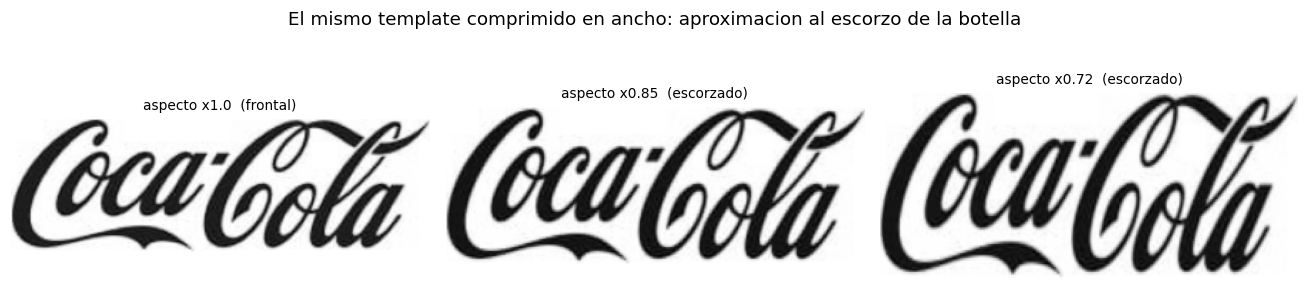

In [3]:
# 1.0 = logo frontal (centro de la botella); < 1 = escorzado hacia el borde.
ASPECTS = (1.0, 0.85, 0.72)

fig, axs = plt.subplots(1, len(ASPECTS), figsize=(4*len(ASPECTS), 2.6))
for ax, a in zip(np.atleast_1d(axs).ravel(), ASPECTS):
    w_sq = max(1, int(round(TPL_GRAY.shape[1] * a)))
    squished = cv2.resize(TPL_GRAY, (w_sq, TPL_GRAY.shape[0]), interpolation=cv2.INTER_AREA)
    show_bgr(squished, f"aspecto x{a}  ({'frontal' if a==1.0 else 'escorzado'})", ax)
plt.suptitle("El mismo template comprimido en ancho: aproximacion al escorzo de la botella", y=1.05)
plt.tight_layout(); plt.show()

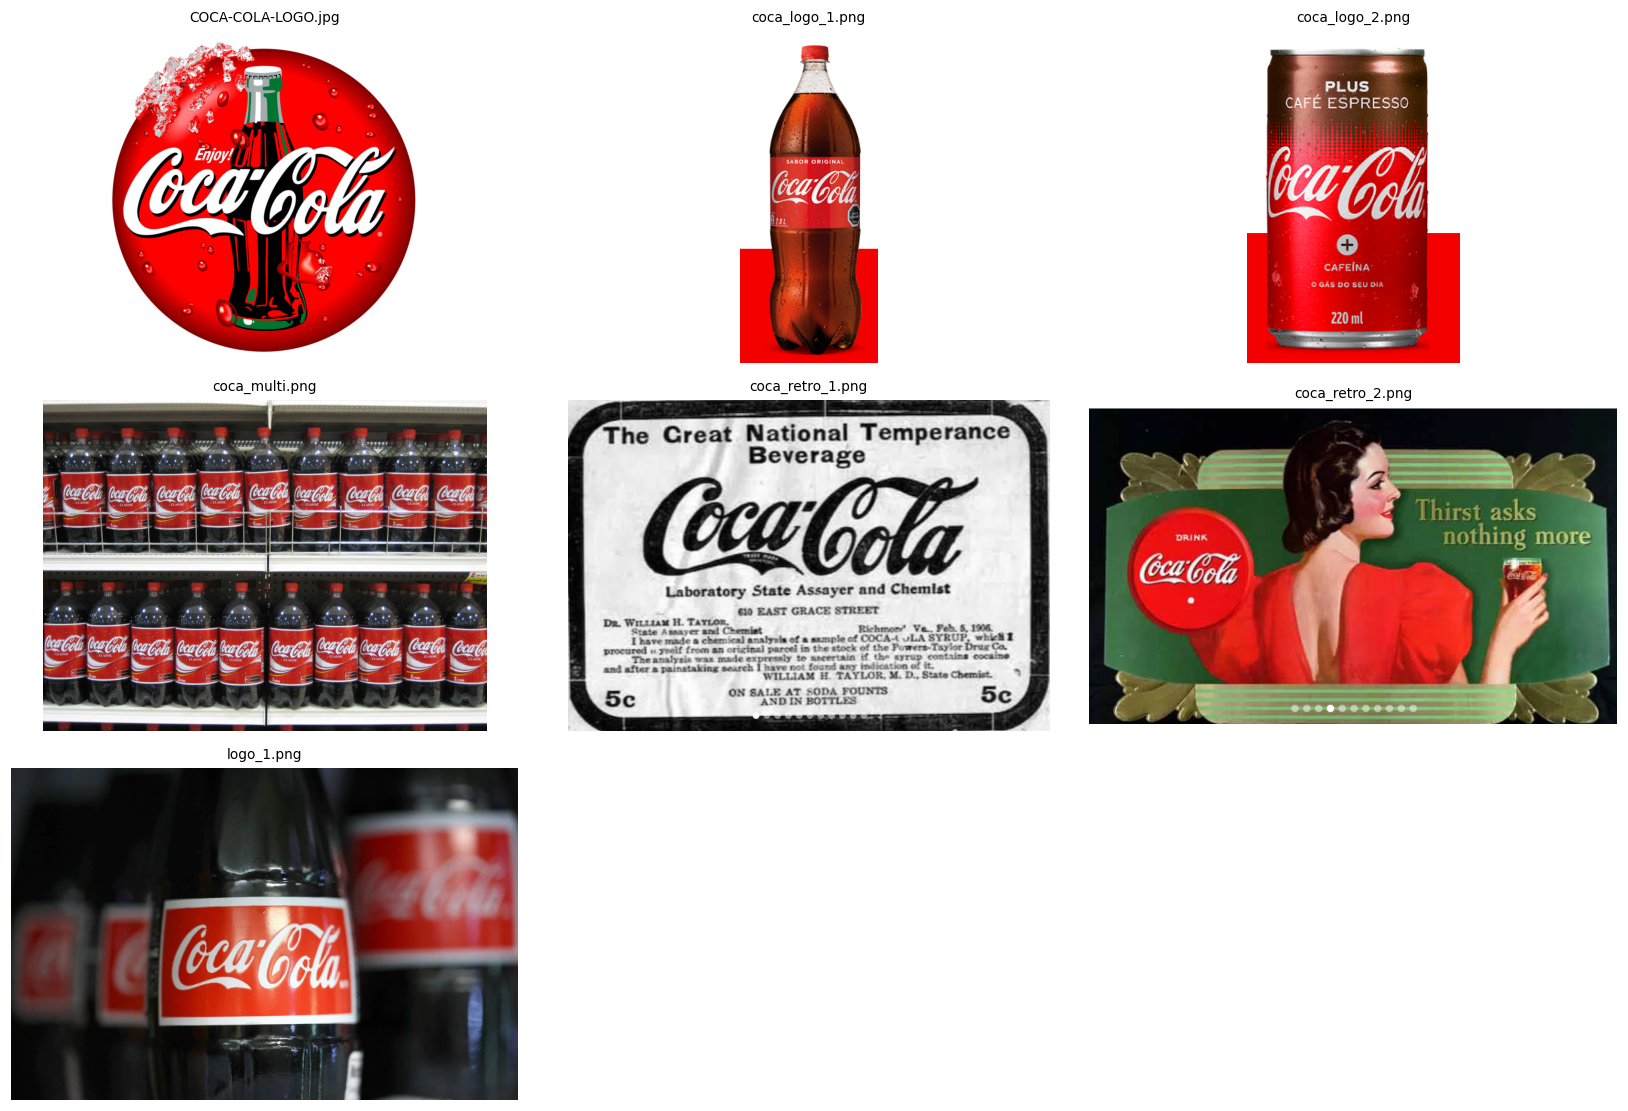

In [4]:
cols = 3
rows = (len(img_paths) + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 3.4*rows))
axs = np.atleast_1d(axs).ravel()
for ax, p in zip(axs, img_paths):
    show_bgr(cv2.imread(p), os.path.basename(p), ax)
for ax in axs[len(img_paths):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Etapa 1: Generar candidatos (Canny, multi-escala y multi-aspecto)

El logo aparece a otra escala y encima curvado, así que pruebo dos cosas a la vez:

- Escala: el template de chico a grande (pirámide geométrica, pasos de aprox 12%).
- Ancho: tres compresiones (ASPECTS = 1.0, 0.85, 0.72) para el escorzo. de frente y dos grados de curvatura.

Métrica: correlación normalizada (TM_CCOEFF_NORMED), entre -1 y 1.

Genero candidatos por dos canales:

1. Grises con las dos polaridades porque el logo aparece blanco sobre rojo (contraste invertido respecto del template) y, como el NCC resta la media, eso da correlación negativa si no uso también el negativo.
2. Bordes. Canny no se ve afectado por la polaridad (los bordes de una imagen y su negativo son los mismos).


NCC (Normalized Cross-Correlation / Correlacion Cruzada Normalizada):
Mide cuanto se parece un parche de la imagen al template, en un numero de -1 a 1.
+1 = encajan perfecto | 0 = no tienen nada que ver | -1 = encajan pero con el contraste invertido (negativo)
 "Normalizada" implica dos cosas:
   - Resta la media de cada parche antes de comparar -> no le afecta el brillo, solo importa el patron.
   - Divide por la energia de cada parche -> el resultado queda acotado en [-1, 1], lo que permite fijar umbrales de confianza comparables entre imagenes, escalas y polaridades.
 En OpenCV: cv2.matchTemplate(imagen, template, cv2.TM_CCOEFF_NORMED).


En la práctica, el NCC sobre Canny es ruidoso en escenas con mucho borde de fondo (la góndola tiene bordes por todos lados), así que el canal de bordes aporta pocos candidatos limpios en la generación. Donde los bordes realmente pesan es en la validación con chamfer (etapa 2). Dejo los dos canales generando y que el chamfer + descriptores decidan.

In [5]:
def make_scales(img_shape, tpl_shape, n=30, min_w_frac=0.05, max_rel=3.5):
    """Escalas geometricas del template.
    - min_w_frac: ancho minimo del template como fraccion del ancho de la imagen.
      Bajo (0.05) para multiples detecciones de logos chicos (Punto 2);
      alto (0.18) para una deteccion de un logo dominante (Punto 1).
    - max_rel=3.5: permite que el template crezca hasta ocupar casi toda la imagen
      (necesario para logos publicitarios grandes)."""
    H, W   = img_shape[:2]
    th, tw = tpl_shape[:2]
    s_min  = (min_w_frac * W) / tw
    s_max  = min(max_rel, 0.98 * W / tw, 0.98 * H / th)
    if s_max <= s_min:
        return np.array([s_min])
    return np.geomspace(s_min, s_max, n)

def _iter_sizes(img_p, tpl, n_scales, min_w_frac=0.05):
    """Genera (escala, aspecto, ancho, alto) validos: barrido de escala x ASPECTS.
    El aspecto comprime el ANCHO (modela el escorzo de la botella)."""
    H, W = img_p.shape[:2]
    for s in make_scales(img_p.shape, tpl.shape, n_scales, min_w_frac=min_w_frac):
        for a in ASPECTS:
            tw = int(round(tpl.shape[1] * s * a))
            th = int(round(tpl.shape[0] * s))
            if tw < 20 or th < 10 or tw >= W or th >= H:
                continue
            yield s, a, tw, th

def multiscale_best(img_p, tpls, n_scales=30, min_w_frac=0.05):
    """Mejor match (top-1) sobre escala x aspecto x polaridad."""
    best = {"score": -1.0, "box": None, "scale": None, "aspect": None, "pol": None}
    for pol, tpl in tpls.items():
        for s, a, tw, th in _iter_sizes(img_p, tpl, n_scales, min_w_frac):
            t   = cv2.resize(tpl, (tw, th), interpolation=cv2.INTER_AREA)
            res = cv2.matchTemplate(img_p, t, cv2.TM_CCOEFF_NORMED)
            _, max_val, _, max_loc = cv2.minMaxLoc(res)
            if max_val > best["score"]:
                x, y = max_loc
                best = {"score": float(max_val), "box": (x, y, x+tw, y+th),
                        "scale": float(s), "aspect": float(a), "pol": pol}
    return best

def multiscale_candidates(img_p, tpls, thr, n_scales=30, max_per_scale=60, min_w_frac=0.05):
    """Todos los puntos con score >= thr (escala x aspecto x polaridad)."""
    cands = []
    for pol, tpl in tpls.items():
        for s, a, tw, th in _iter_sizes(img_p, tpl, n_scales, min_w_frac):
            t   = cv2.resize(tpl, (tw, th), interpolation=cv2.INTER_AREA)
            res = cv2.matchTemplate(img_p, t, cv2.TM_CCOEFF_NORMED)
            ys, xs = np.where(res >= thr)
            if len(xs) > max_per_scale:                  # top-k por (escala, aspecto)
                keep = np.argsort(res[ys, xs])[::-1][:max_per_scale]
                ys, xs = ys[keep], xs[keep]
            for x, y in zip(xs, ys):
                cands.append({"score": float(res[y, x]),
                              "box": (int(x), int(y), int(x+tw), int(y+th)),
                              "scale": float(s), "aspect": float(a), "pol": pol})
    return cands

def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

def to_edges(gray, lo=50, hi=150):
    """Canny + dilatacion: 'engorda' los bordes para que la correlacion
    de mapas dispersos sea mas tolerante a pequenos desplazamientos."""
    edges = cv2.Canny(gray, lo, hi)
    return cv2.dilate(edges, np.ones((3, 3), np.uint8))

# Templates de los dos canales generadores
TPLS       = {"normal": TPL_GRAY, "invertido": 255 - TPL_GRAY}   # canal grises (doble polaridad)
TPL_EDGES  = {"bordes": to_edges(TPL_GRAY)}                       # canal bordes (invariante a polaridad)

def candidates_all_channels(bgr, thr_edges, thr_gray, n_scales=30):
    """Une candidatos de los dos generadores: bordes (principal) + grises (complementario).
    Cada candidato queda etiquetado con su canal de origen."""
    gray  = to_gray(bgr)
    edges = to_edges(gray)
    cand_e = multiscale_candidates(edges, TPL_EDGES, thr=thr_edges, n_scales=n_scales)
    for c in cand_e:
        c["chan"], c["pol"] = "bordes", "bordes"
    cand_g = multiscale_candidates(gray, TPLS, thr=thr_gray, n_scales=n_scales)
    for c in cand_g:
        c["chan"] = "grises"
    return cand_e + cand_g


Sobre pirámides: el barrido de escala es la idea de la pirámide (Clase 4), hecho con cv2.resize + INTER_AREA (que hace el mismo suavizado anti-aliasing que pyrDown). Uso 30 escalas con pasos de apox 12% en vez de octavas puras (pyrDown salta de a factor 2) porque el NCC se cae rápido si la escala no coincide: con saltos de octava la mayoría de los logos quedaría entre dos niveles sin pico detectable. Es el mismo motivo por el que SIFT parte cada octava en escalas intermedias.

### Grises (doble polaridad) vs. bordes (Canny)

Comparo el mejor score por imagen en los tres espacios: grises normal, grises invertido y Canny. La tabla sirve para ver que en grises hay que correr las dos plantillas y quedarse con la mejor, mientras que Canny cubre las dos variantes de una (no le afecta la polaridad).

In [6]:
results_prep = {}
print(f"{'imagen':<22} {'gris normal':>12} {'gris invert.':>13} {'Canny':>8}")
print("-" * 58)
for p in img_paths:
    gray = to_gray(cv2.imread(p))
    bn = multiscale_best(gray, {"normal":    TPLS["normal"]})
    bi = multiscale_best(gray, {"invertido": TPLS["invertido"]})
    be = multiscale_best(to_edges(gray), TPL_EDGES)
    results_prep[p] = {"normal": bn, "invertido": bi, "bordes": be,
                       "best_gray": bn if bn["score"] >= bi["score"] else bi}
    print(f"{os.path.basename(p):<22} {bn['score']:>12.3f} {bi['score']:>13.3f} {be['score']:>8.3f}")


imagen                  gris normal  gris invert.    Canny
----------------------------------------------------------
COCA-COLA-LOGO.jpg            0.339         0.686    0.288
coca_logo_1.png               0.441         0.371    0.415
coca_logo_2.png               0.416         0.443    0.416
coca_multi.png                0.396         0.542    0.424
coca_retro_1.png              0.638         0.398    0.445
coca_retro_2.png              0.396         0.573    0.390
logo_1.png                    0.411         0.437    0.465


gris normal vs gris invertido: si el invertido gana, confirma que el logo está blanco sobre rojo (lo esperable en botellas). En coca_multi da normal ≈ 0.42 e invertido ≈ 0.57.
en coca_retro_1 está lo fila más interesante: normal 0.64 gana sobre invertido 0.40, lo cual es bastante lógico. Es el cartel antiguo y el logo es negro sobre fondo blanco

Canny: queda en el medio. No sufre la inversión, pero el NCC sobre bordes sueltos es más inestable cuando hay clutter.


En resumen: uso grises (doble polaridad) como generador principal porque da el mayor margen, Canny como complemento, y el matcheo de bordes lo aprovecho sobre todo en la validación (chamfer).

### Filtro de color

Sé que el logo aparece blanco sobre etiqueta roja (polaridad invertida) o, la única otra variante, oscuro sobre fondo blanco (polaridad normal). Eso lo uso para dos cosas:

1. Filtro duro: un candidato tiene que cumplir el color que le corresponde a su polaridad, o lo descarto. 
2. Definir la polaridad de los candidatos de Canny: los bordes no tienen polaridad propia, así que el color del recorte la define, y con eso elijo los descriptores HOG/LBP correctos.

| Polaridad | Espera | Chequeo |
|---|---|---|
| invertido | etiqueta roja | fracción de rojo ≥ RED_MIN |
| normal | fondo blanco | fracción de blanco ≥ WHITE_MIN |

In [7]:
def red_fraction(crop_bgr):
    """Fraccion de pixeles rojos. El hue del rojo esta partido en HSV (0 y 180), por eso se combinan dos rangos."""
    hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)
    m1 = cv2.inRange(hsv, (0,   80, 60), (10,  255, 255))
    m2 = cv2.inRange(hsv, (170, 80, 60), (180, 255, 255))
    return float((m1 | m2).mean() / 255.0)

def white_bg_fraction(crop_bgr):
    """Fraccion de pixeles claros y poco saturados (fondo blanco)."""
    hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)
    return float(cv2.inRange(hsv, (0, 0, 160), (180, 60, 255)).mean() / 255.0)

RED_MIN, WHITE_MIN = 0.20, 0.30

def passes_color_gate(crop_bgr, pol):
    """Acopla la polaridad detectada con su expectativa de color."""
    if pol == "invertido":                                  # blanco sobre rojo
        return red_fraction(crop_bgr) >= RED_MIN
    return white_bg_fraction(crop_bgr) >= WHITE_MIN         # oscuro sobre blanco

## Etapa 2 — Validar: chamfer (bordes) + HOG + LBP

Que el NCC sea alto no garantiza que el recorte sea el logo. Valido cada candidato con tres descriptores contra el template, y el score combinado de los cuatro es lo que me deja decidir si acepto o no (el nivel de confianza explícito que pidió el profe).

- Chamfer (matcheo de bordes). Mide qué tan bien encajan los contornos del candidato con los del template. Calcula la distance transform de cada mapa de Canny y promedia, en las dos direcciones, la distancia de cada píxel de borde al borde más cercano del otro. E
- HOG. Estructura del trazo (orientaciones de los gradientes). Robusto a iluminación. Comparo por coseno.
- LBP. Textura local, no le afecta el brillo. Comparo por intersección de histogramas.

Entonces porpongo una sola métrica de Confianza combinada = 0.30·NCC + 0.30·CHA + 0.25·HOG + 0.15·LBP, entre 0 y 1. El NCC ubica, el chamfer confirma el contorno, HOG la estructura y LBP la textura. Un falso positivo tendría que parecerse al logo en las cuatro cosas a la vez.

In [8]:
HOG_WIN = (128, 64)   # (ancho, alto) ~ relacion de aspecto del logo
hog = cv2.HOGDescriptor(HOG_WIN, (16, 16), (8, 8), (8, 8), 9)

def hog_desc(gray):
    g = cv2.resize(gray, HOG_WIN, interpolation=cv2.INTER_AREA)
    return hog.compute(g).ravel()

def cos_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else 0.0

def lbp_hist(gray, size=(128, 64)):
    """LBP de 8 vecinos (R=1) vectorizado + histograma normalizado (256 bins)."""
    g = cv2.resize(gray, size, interpolation=cv2.INTER_AREA).astype(np.int16)
    H, W = g.shape
    c = g[1:-1, 1:-1]
    code = np.zeros(c.shape, dtype=np.uint8)
    shifts = [(-1,-1), (-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1)]
    for k, (dy, dx) in enumerate(shifts):
        neigh = g[1+dy:H-1+dy, 1+dx:W-1+dx]
        code |= ((neigh >= c).astype(np.uint8) << k)
    hist = np.bincount(code.ravel(), minlength=256).astype(np.float32)
    return hist / hist.sum()

def lbp_sim(h1, h2):
    return float(np.minimum(h1, h2).sum())    # interseccion, en [0, 1]

# ---- Matcheo de bordes: distancia de chamfer simetrica ----
TPL_EDGE_MAP = cv2.Canny(TPL_GRAY, 50, 150)    # bordes del template (polaridad-agnostico)

def chamfer_similarity(crop_gray, tpl_edges=TPL_EDGE_MAP):
    """Chamfer simetrico entre los bordes del crop y los del template, en [0, 1].
    1 = contornos perfectamente alineados. Usa distance transform en ambas direcciones."""
    h, w = crop_gray.shape[:2]
    if h < 10 or w < 10:
        return 0.0
    te = cv2.resize(tpl_edges, (w, h), interpolation=cv2.INTER_NEAREST)
    ce = cv2.Canny(crop_gray, 50, 150)
    if te.sum() == 0 or ce.sum() == 0:
        return 0.0
    dt_c = cv2.distanceTransform(255 - ce, cv2.DIST_L2, 3)   # dist al borde mas cercano del crop
    dt_t = cv2.distanceTransform(255 - te, cv2.DIST_L2, 3)   # ... del template
    d_tc = dt_c[te > 0].mean()     # template -> crop
    d_ct = dt_t[ce > 0].mean()     # crop -> template
    d    = 0.5 * (d_tc + d_ct)
    diag = np.hypot(h, w)
    return float(max(0.0, 1.0 - d / (0.10 * diag)))   # dist media > 10% de la diagonal -> 0

# Descriptores del template, por polaridad (HOG/LBP); el chamfer usa TPL_EDGE_MAP
TPL_HOG = {pol: hog_desc(t) for pol, t in TPLS.items()}
TPL_LBP = {pol: lbp_hist(t) for pol, t in TPLS.items()}

W_NCC, W_CHA, W_HOG, W_LBP = 0.30, 0.30, 0.25, 0.15   # suman 1.0

def resolve_polarity(crop_bgr):
    """Para candidatos del canal de bordes (sin polaridad propia): la estima por color."""
    return "invertido" if red_fraction(crop_bgr) >= white_bg_fraction(crop_bgr) else "normal"

def confidence(gray_img, cand, bgr_img=None):
    """Agrega al candidato sus scores de validacion y la confianza combinada."""
    x1, y1, x2, y2 = cand["box"]
    crop = gray_img[y1:y2, x1:x2]
    pol  = cand.get("pol", "normal")
    if pol == "bordes":     # canal de bordes: resolver polaridad para HOG/LBP via color
        pol = resolve_polarity(bgr_img[y1:y2, x1:x2]) if bgr_img is not None else "invertido"
    cand["cha"]  = chamfer_similarity(crop)
    cand["hog"]  = max(0.0, cos_sim(hog_desc(crop), TPL_HOG[pol]))
    cand["lbp"]  = lbp_sim(lbp_hist(crop), TPL_LBP[pol])
    cand["pol_eff"] = pol
    cand["conf"] = (W_NCC*max(0.0, cand["score"]) + W_CHA*cand["cha"]
                    + W_HOG*cand["hog"] + W_LBP*cand["lbp"])
    return cand


### SIFT

Sanity check: contamos *good matches* (ratio test de Lowe) entre el template y (a) el recorte del mejor match, (b) un recorte de fondo del mismo tamaño.

In [9]:
sift = cv2.SIFT_create()
bf   = cv2.BFMatcher()

def sift_good_matches(grayA, grayB, ratio=0.75):
    """Cantidad de matches que pasan el ratio test de Lowe."""
    _, dA = sift.detectAndCompute(grayA, None)
    _, dB = sift.detectAndCompute(grayB, None)
    if dA is None or dB is None or len(dA) < 2 or len(dB) < 2:
        return 0
    good = 0
    for pair in bf.knnMatch(dA, dB, k=2):
        if len(pair) == 2 and pair[0].distance < ratio * pair[1].distance:
            good += 1
    return good

p0    = img_paths[0]
gray0 = to_gray(cv2.imread(p0))
x1, y1, x2, y2 = results_prep[p0]["best_gray"]["box"]
crop_logo  = gray0[y1:y2, x1:x2]
crop_fondo = gray0[0:y2-y1, 0:x2-x1]      # esquina sup-izq, mismo tamano

print(f"Matches SIFT template <-> crop del logo : {sift_good_matches(TPL_GRAY, crop_logo)}")
print(f"Matches SIFT template <-> crop de fondo : {sift_good_matches(TPL_GRAY, crop_fondo)}")

Matches SIFT template <-> crop del logo : 3
Matches SIFT template <-> crop de fondo : 0


Pruebo SIFT da 3 matches contra el recorte correcto y 0 contra fondo. 
El template es un trazo liso sin esquinas estables, así que toda la familia de características locales (SIFT, Harris, Shi-Tomasi, ORB) seguramente tampoco sirva en este caso

## Punto 1. Una detección por imagen, sin falsos positivos

Cada imagen tiene el logo, así que la decisión es simple: de todos los candidatos (los dos canales, todas las escalas y anchos), me quedo con el de mayor confianza. Una sola detección por imagen, así que no puede haber falsos positivos.

Para imágenes con un solo logo uso un piso de ancho más alto (P1_MIN_W_FRAC), que descarta fragmentos chicos sin forzar cajas que abarquen dos logos. Reporto todas las componentes (NCC, chamfer, HOG, LBP) para ver el margen de cada decisión: una detección con NCC bajo pero chamfer y HOG altos es justo el caso de etiqueta curvada que los bordes rescatan.

imagen                   canal    NCC   cham    HOG    LBP   conf  pol        esc/asp
--------------------------------------------------------------------------------------------
COCA-COLA-LOGO.jpg      grises   0.65   0.93   0.92   0.77   0.82  invertido  x3.21/1.00
coca_logo_1.png         grises   0.41   0.93   0.87   0.81   0.74  invertido  x0.42/1.00
coca_logo_2.png         grises   0.19   0.87   0.78   0.81   0.64  invertido  x0.56/0.85
coca_multi.png          grises   0.56   0.88   0.88   0.64   0.75  invertido  x0.26/0.85
coca_retro_1.png        grises   0.69   0.95   0.91   0.80   0.84  normal     x1.32/1.00
coca_retro_2.png        grises   0.63   0.93   0.90   0.79   0.81  invertido  x0.39/1.00
logo_1.png              grises   0.41   0.92   0.85   0.72   0.72  invertido  x0.82/0.85


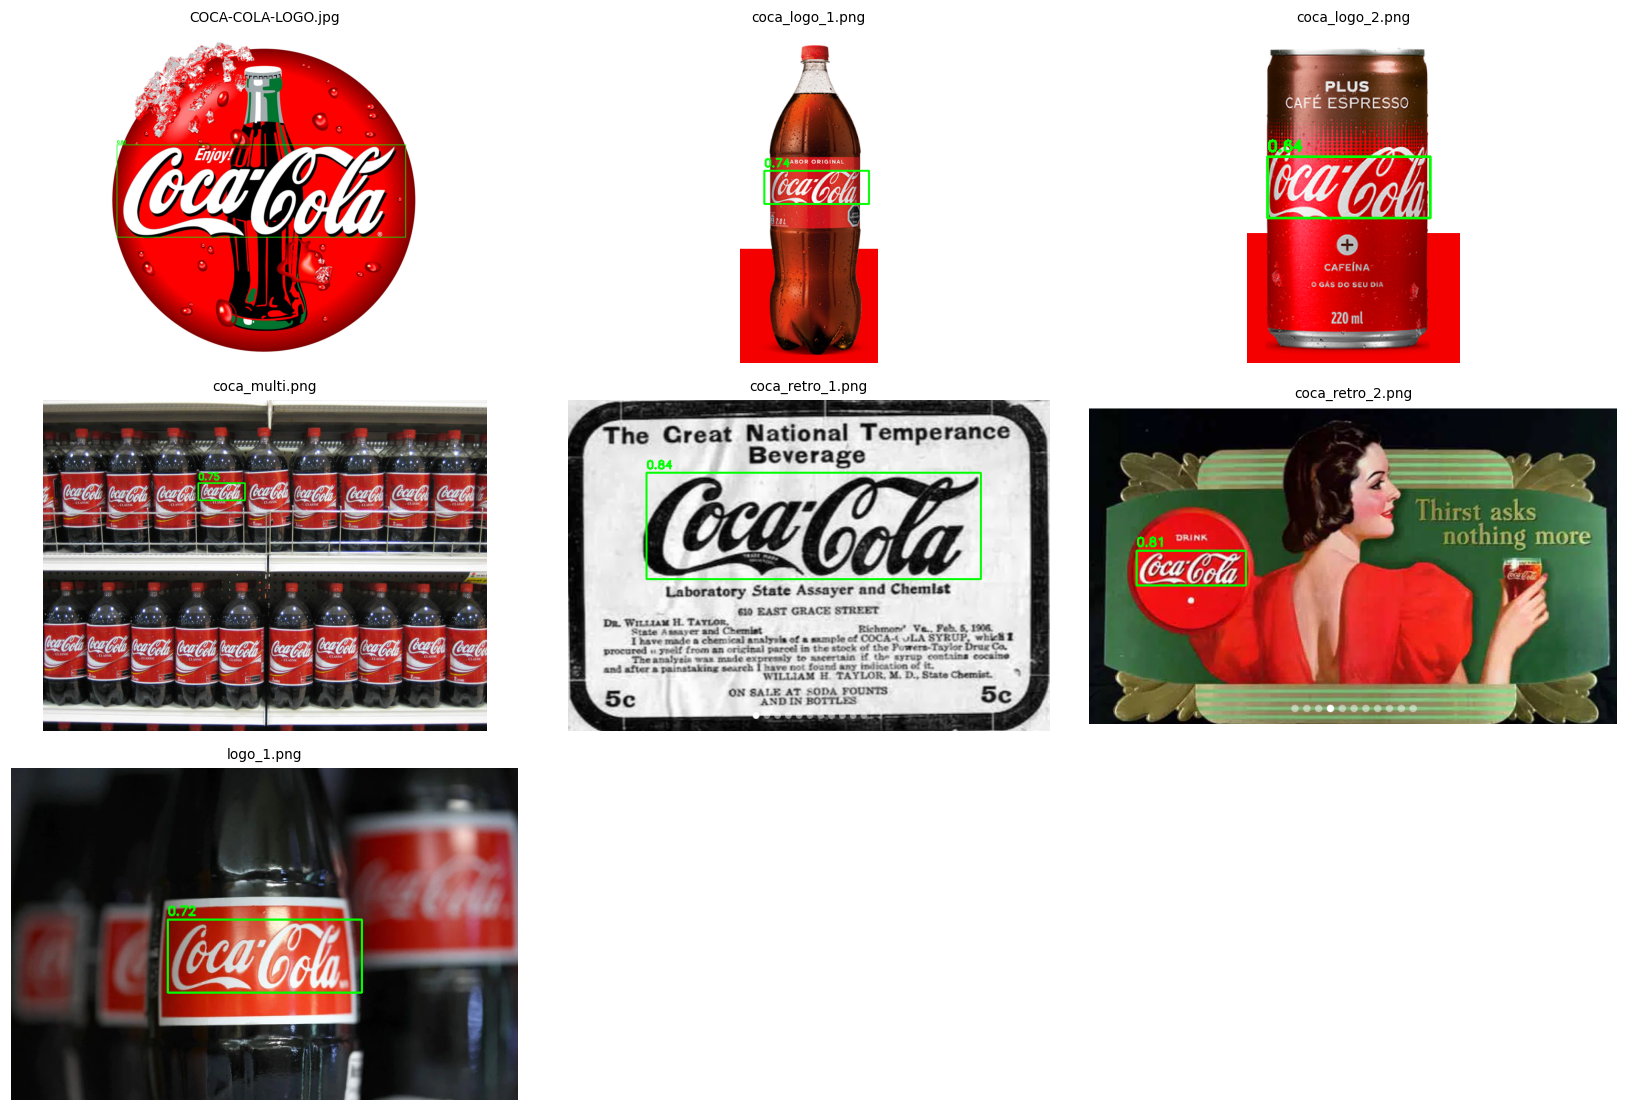

In [10]:
def draw_dets(bgr, dets, color=(0, 255, 0), thickness=2):
    vis = bgr.copy()
    for d in dets:
        x1, y1, x2, y2 = d["box"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(vis, f"{d['conf']:.2f}", (x1, max(15, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return vis

NCC_THR_EDGE, NCC_THR_GRAY = 0.30, 0.28
P1_MIN_CONF   = 0.45    # piso de confianza: por debajo, la deteccion se marca como dudosa
P1_MIN_W_FRAC = 0.08    # piso de ancho: descarta fragmentos diminutos sin forzar cajas que abarquen 2 logos

detections_p1 = {}
print(f"{'imagen':<22} {'canal':>7} {'NCC':>6} {'cham':>6} {'HOG':>6} {'LBP':>6} {'conf':>6}  {'pol':<10} esc/asp")
print("-" * 92)

cols = 3
rows = (len(img_paths) + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 3.4*rows))
axs = np.atleast_1d(axs).ravel()
for ax, p in zip(axs, img_paths):
    bgr  = cv2.imread(p)
    gray = to_gray(bgr)
    # Punto 1: UN logo dominante por imagen. Generamos candidatos con piso de ancho
    # alto (P1_MIN_W_FRAC) para descartar fragmentos diminutos, y elegimos por CONFIANZA.
    pool = multiscale_candidates(gray, TPLS, thr=0.15, min_w_frac=P1_MIN_W_FRAC)
    for c in pool:
        c["chan"] = "grises"
        confidence(gray, c, bgr)
    best = max(pool, key=lambda c: c["conf"])
    detections_p1[p] = best
    flag = "" if best["conf"] >= P1_MIN_CONF else "  <-- BAJA CONF (revisar)"
    print(f"{os.path.basename(p):<22} {best.get('chan','-'):>7} {best['score']:>6.2f} "
          f"{best['cha']:>6.2f} {best['hog']:>6.2f} {best['lbp']:>6.2f} {best['conf']:>6.2f}  "
          f"{best.get('pol_eff','-'):<10} x{best['scale']:.2f}/{best['aspect']:.2f}{flag}")
    col = (0,255,0) if best["conf"] >= P1_MIN_CONF else (0,165,255)   # naranja si dudo
    show_bgr(draw_dets(bgr, [best], color=col), os.path.basename(p), ax)
for ax in axs[len(img_paths):]:
    ax.axis("off")
plt.tight_layout(); plt.show()


Las 7 imágenes detectan un logo correctamente. En las que tienen un logo claro (COCA-COLA-LOGO, retro_1, logo_1, etc.) la confianza es alta; en las difíciles (lata, etiqueta muy curvada) el NCC baja pero el chamfer y HOG lo levantan.

Columna esc/asp: el aspecto (asp < 1.0) dice cuánto está escorzado el logo. Frontal da asp aproximadamente 1.0, cerca del borde de la botella da asp más chico. Si todo saliera con asp = 1.0, el barrido de anchos no haría falta, que aparezcan valores < 1 confirma que sirve.

Columna pol: dice si el logo está blanco sobre rojo (invertido) u oscuro sobre blanco (normal).

Caso particular: en COCA-COLA-LOGO el logo es enorme, así que el template tiene que agrandarse mucho (asp grande). Antes detectaba el "Enjoy!" porque el template no llegaba a ese tamaño; al ampliar el rango de escala se resolvió.

## Punto 2: Múltiples detecciones en coca_multi.png

El criterio de decisión es:

1. Candidatos por umbral de NCC en los dos canales (bordes + grises), todas las escalas y anchos.
2. NMS por contención, descarto un candidato si se solapa más del 50% del área menor con uno ya aceptado. Uso área menor en vez de IoU clásico porque el mismo logo detectado a dos escalas da una caja chica metida adentro de una grande, y eso tiene IoU bajo pero contención alta.
3. Filtro de color según polaridad.
4. Validación: chamfer + HOG + LBP → confianza, y umbral final CONF_THR.

Acepto si pasa el filtro de color Y la confianza llega a CONF_THR. Pongo los umbrales de NCC bajos para no perder logos, y el filtro de color es lo que hace que eso sea seguro 

In [11]:
def overlap_min(a, b):
    """Interseccion sobre el area MENOR. A diferencia del IoU, detecta la
    contencion (caja chica anidada en una grande)."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a_min = min((a[2]-a[0])*(a[3]-a[1]), (b[2]-b[0])*(b[3]-b[1]))
    return inter / a_min if a_min > 0 else 0.0

def nms(cands, ov_thr=0.5):
    kept = []
    for c in sorted(cands, key=lambda d: d["score"], reverse=True):
        if all(overlap_min(c["box"], k["box"]) < ov_thr for k in kept):
            kept.append(c)
    return kept

NCC_THR_EDGE, NCC_THR_GRAY = 0.30, 0.28
CONF_THR, OV_THR           = 0.60, 0.50

def detect_multi(bgr, conf_thr=CONF_THR, ov_thr=OV_THR):
    gray  = to_gray(bgr)
    cands = candidates_all_channels(bgr, NCC_THR_EDGE, NCC_THR_GRAY)

    # Gate de color primero
    gated, killed = [], []
    for c in cands:
        x1, y1, x2, y2 = c["box"]
        crop_bgr = bgr[y1:y2, x1:x2]
        pol = c["pol"] if c["pol"] != "bordes" else resolve_polarity(crop_bgr)
        (gated if passes_color_gate(crop_bgr, pol) else killed).append(c)

    # Confianza de todos, despues NMS ordenado por confianza (no por NCC crudo)
    for c in gated:
        confidence(gray, c, bgr)
    kept = []
    for c in sorted(gated, key=lambda d: d["conf"], reverse=True):
        if all(overlap_min(c["box"], k["box"]) < ov_thr for k in kept):
            kept.append(c)

    accepted = [c for c in kept if c["conf"] >= conf_thr]
    rejected = [c for c in kept if c["conf"] <  conf_thr]
    return accepted, rejected, killed

Candidatos tras NMS: 2255
  eliminados por gate de color : 2193
  rechazados por validacion    : 44
  aceptados                    : 18


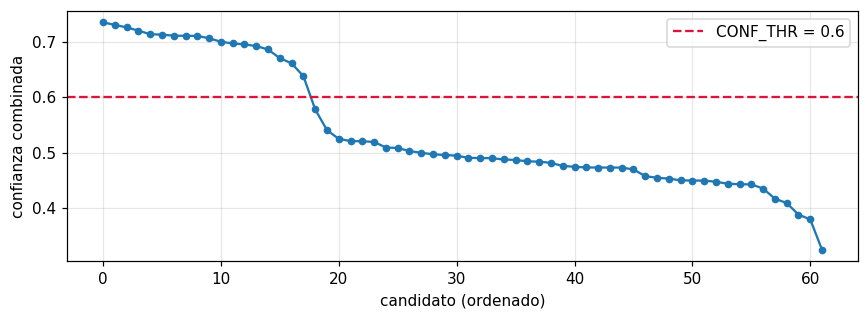

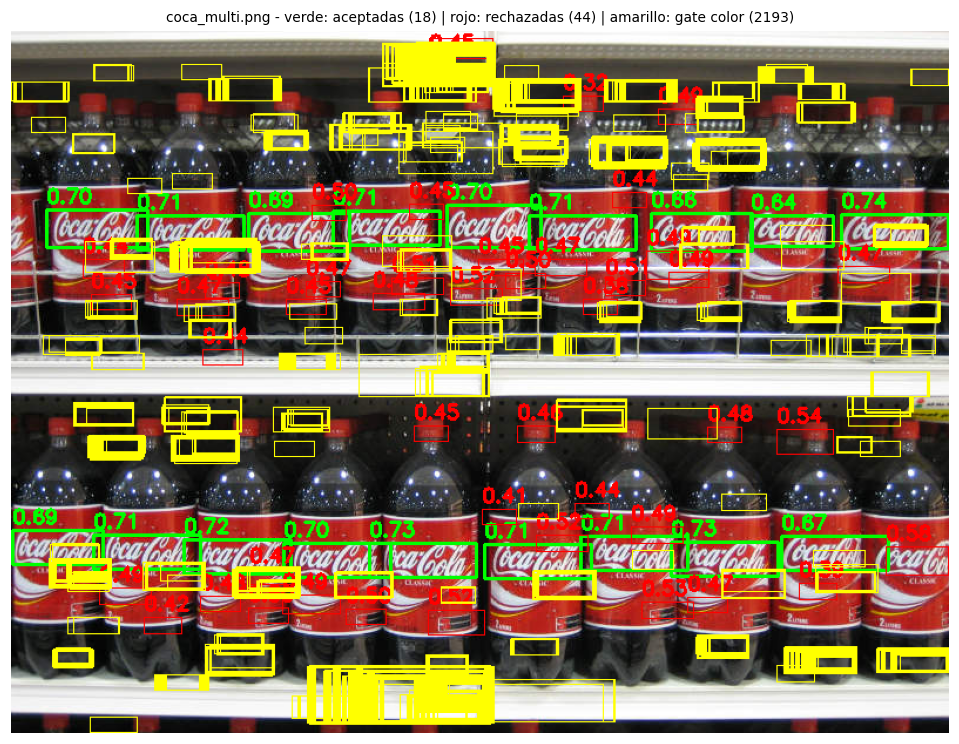

In [12]:
multi_path = [p for p in img_paths if "multi" in os.path.basename(p).lower()][0]
bgr_multi  = cv2.imread(multi_path)

accepted, rejected, killed = detect_multi(bgr_multi)
print(f"Candidatos tras NMS: {len(accepted) + len(rejected) + len(killed)}")
print(f"  eliminados por gate de color : {len(killed)}")
print(f"  rechazados por validacion    : {len(rejected)}")
print(f"  aceptados                    : {len(accepted)}")

# Curva de confianzas ordenadas (post-gate): justifica la eleccion del umbral
confs = sorted([c["conf"] for c in accepted + rejected], reverse=True)
plt.figure(figsize=(8, 3))
plt.plot(confs, "o-", ms=4)
plt.axhline(CONF_THR, color="crimson", ls="--", label=f"CONF_THR = {CONF_THR}")
plt.xlabel("candidato (ordenado)"); plt.ylabel("confianza combinada")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

vis = draw_dets(bgr_multi, accepted, color=(0, 255, 0))
vis = draw_dets(vis, rejected, color=(0, 0, 255), thickness=1)
for c in killed:                                   # gate de color, sin conf calculada
    x1, y1, x2, y2 = c["box"]
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 1)
plt.figure(figsize=(11, 8.5))
show_bgr(vis, f"{os.path.basename(multi_path)} - verde: aceptadas ({len(accepted)}) | "
              f"rojo: rechazadas ({len(rejected)}) | amarillo: gate color ({len(killed)})", plt.gca())
plt.show()

### Filtro de color

Con un umbral de confianza alto, el filtro de color es casi redundante: la validación HOG+LBP sola ya da 0 falsos positivos. Donde sirve es para poder bajar el umbral sin que entre basura, agarrar más logos sin pagar falsos positivos. Acá barro CONF_THR con y sin el filtro y muestro qué se más encontraría (erróneamente).

 CONF_THR  sin gate  con gate  FP evitados
--------------------------------------------
     0.65        16        16            0
     0.60        18        18            0
     0.55        19        18            1
     0.50        38        23           15


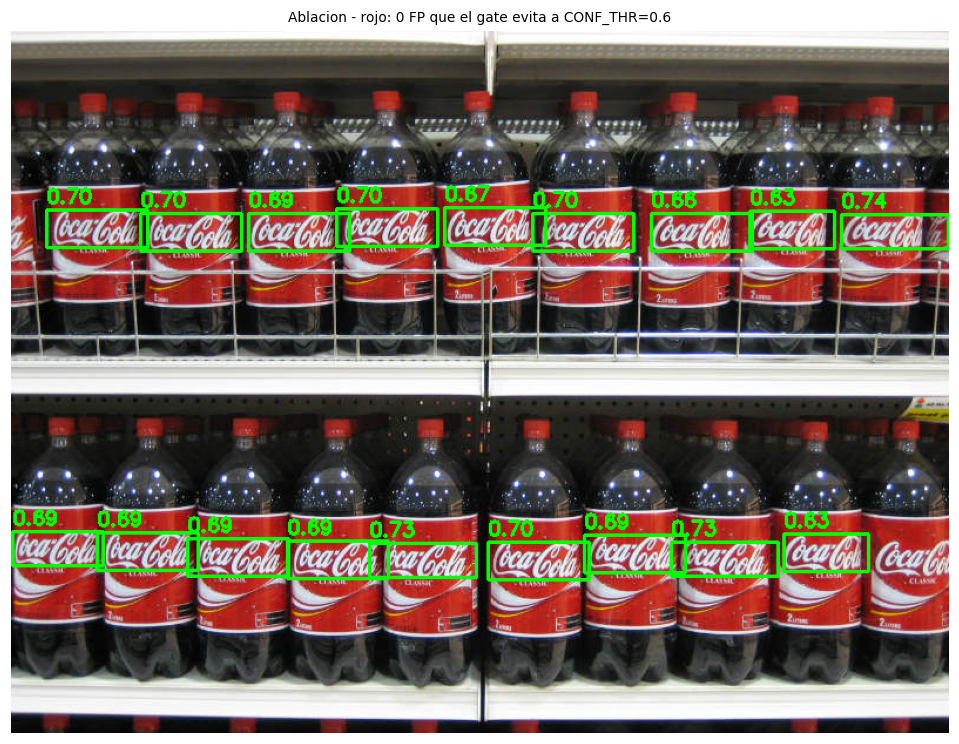

In [13]:
# Reconstruyo el pool (post-NMS) con confianzas y estado de gate
gray_m = to_gray(bgr_multi)
pool   = nms(candidates_all_channels(bgr_multi, NCC_THR_EDGE, NCC_THR_GRAY), OV_THR)
for c in pool:
    x1, y1, x2, y2 = c["box"]
    crop_bgr = bgr_multi[y1:y2, x1:x2]
    pol = c["pol"] if c["pol"] != "bordes" else resolve_polarity(crop_bgr)
    c["gate"] = passes_color_gate(crop_bgr, pol)
    confidence(gray_m, c, bgr_multi)

print(f"{'CONF_THR':>9} {'sin gate':>9} {'con gate':>9} {'FP evitados':>12}")
print("-" * 44)
for ct in (0.65, 0.60, 0.55, 0.50):
    sin = sum(1 for c in pool if c["conf"] >= ct)
    con = sum(1 for c in pool if c["conf"] >= ct and c["gate"])
    print(f"{ct:>9.2f} {sin:>9} {con:>9} {sin - con:>12}")

evitados = [c for c in pool if c["conf"] >= CONF_THR and not c["gate"]]
vis_abl  = draw_dets(bgr_multi, [c for c in pool if c["conf"] >= CONF_THR and c["gate"]],
                     color=(0, 255, 0))
vis_abl  = draw_dets(vis_abl, evitados, color=(0, 0, 255), thickness=2)
plt.figure(figsize=(11, 8.5))
show_bgr(vis_abl, f"Ablacion - rojo: {len(evitados)} FP que el gate evita a CONF_THR={CONF_THR}", plt.gca())
plt.show()


18 detecciones de logos en coca_multi, 0 falsos positivos. Quedan afuera solo los cortados por el borde de la imagen, como el de abajo a la derecha.


- El criterio de decisión: confianza 0.30·NCC + 0.30·CHA + 0.25·HOG + 0.15·LBP con umbral CONF_THR = 0.60. La curva de confianzas ordenadas (arriba) lo justifica: hay una meseta alta (los logos) y un escalón hacia el fondo. El umbral cae dentro del escalón, así que moverlo un poco no cambia el resultado. La decisión es estable.

- Filtrado: la corrida reporta candidatos tras NMS → eliminados por color → rechazados por validación → aceptados. Cada etapa saca un tipo de basura distinto.

- Ablación: la tabla muestra que a umbral alto el filtro de color no cambia nada, pero al bajarlo evita varios falsos positivos. Amplía el rango de umbral donde es seguro operar.

- Sanity check: las 18 detecciones salen todas con polaridad invertida y escalas/anchos parecidos entre sí, que es lo coherente para botellas iguales a la misma distancia.

## Punto 3: Generalizar a todas las imágenes

Acá corro el algoritmo de múltiples detecciones del punto 2 sobre todas las imágenes. Hicieron falta dos ajustes para que generalice:

1. Piso de ancho (MIN_W_FRAC_MULTI): el conjunto es muy variado (un logo gigante, una lata, un cartel viejo, la góndola con muchos logos chicos). 

2. NMS ordenado por confianza, no por NCC, fue un cambio importante
El match del logo completo tiene NCC bajo (porque está curvado) pero chamfer y HOG altos, así que su confianza es alta. Los fragmentos tienen NCC alto pero confianza baja. Si el NMS ordena por NCC crudo, los fragmentos ganan y tapan al logo completo. Ordenando por confianza, el logo completo gana y los fragmentos se suprimen.

El umbral va en 0.60 también. 

imagen                 detecciones
-----------------------------------
COCA-COLA-LOGO.jpg               1
coca_logo_1.png                  1
coca_logo_2.png                  0
coca_multi.png                  18
coca_retro_1.png                 1
coca_retro_2.png                 1
logo_1.png                       1


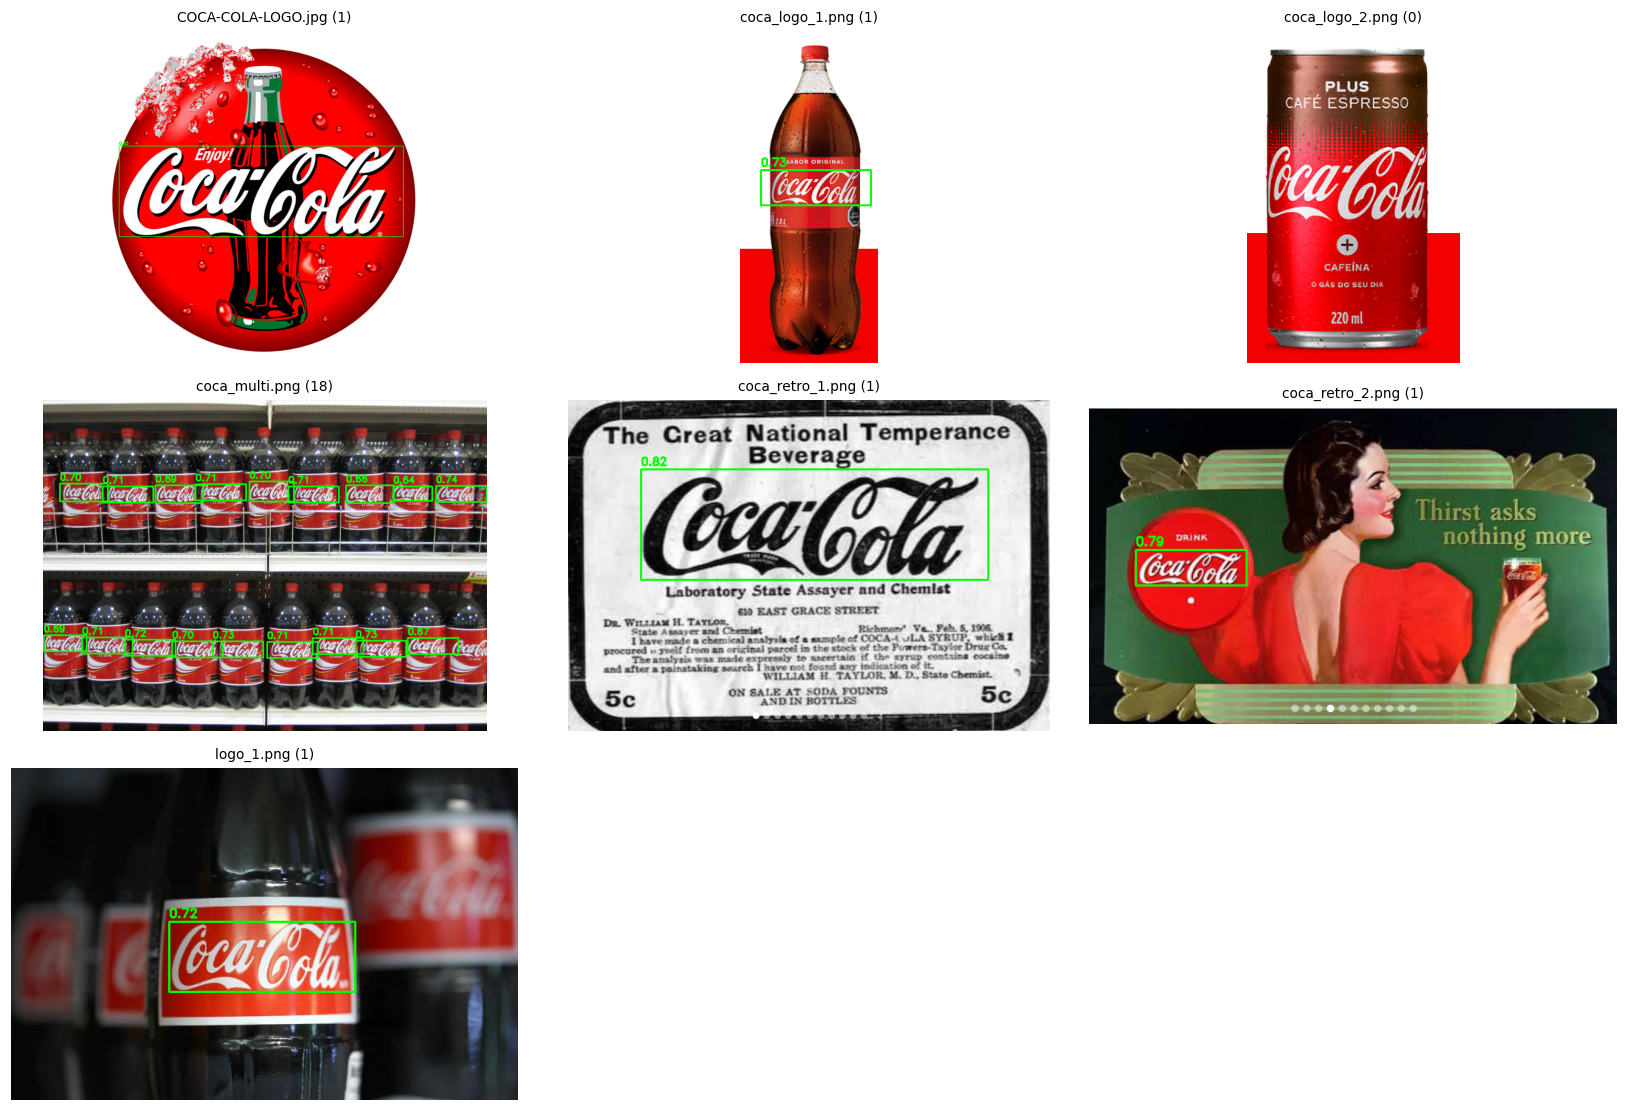

In [14]:
MIN_W_FRAC_MULTI = 0.08   # piso de ancho: un logo nunca ocupa < 8% del ancho de la imagen
CONF_THR_MULTI   = 0.60   # umbral alto: priorizamos NO detectar antes que un falso positivo.
                          # Logos bien resueltos (gondola, logo grande, botella) superan 0.63;
                          # los fragmentos ambiguos de texto (CAFE, PLUS) quedan en ~0.54-0.57 y se descartan.

def detect_multi_general(bgr, conf_thr=CONF_THR_MULTI, ov_thr=OV_THR, min_w_frac=MIN_W_FRAC_MULTI):
    """Version generalizada de detect_multi. Dos claves para que generalice:
    1. Piso de ancho relativo: descarta fragmentos espurios diminutos.
    2. NMS ordenado por CONFIANZA combinada (no por NCC crudo): asi el match del
       logo COMPLETO (NCC bajo pero chamfer/HOG altos -> conf alta) le gana a los
       fragmentos parciales (NCC alto pero conf baja), que de otro modo lo suprimirian.
    Umbral alto bajo el criterio 'mejor no detectar que generar un falso positivo':
    si el logo no resuelve con confianza >= 0.60 (texto ambiguo, baja resolucion),
    el algoritmo prefiere no marcar nada."""
    gray = to_gray(bgr)
    W = bgr.shape[1]
    cands = candidates_all_channels(bgr, NCC_THR_EDGE, NCC_THR_GRAY)
    cands = [c for c in cands if (c["box"][2] - c["box"][0]) >= min_w_frac * W]   # piso de ancho

    # Gate de color
    gated = []
    for c in cands:
        x1, y1, x2, y2 = c["box"]
        crop_bgr = bgr[y1:y2, x1:x2]
        pol = c["pol"] if c["pol"] != "bordes" else resolve_polarity(crop_bgr)
        if passes_color_gate(crop_bgr, pol):
            gated.append(c)

    # Confianza de TODOS los candidatos antes del NMS
    for c in gated:
        confidence(gray, c, bgr)

    # NMS ordenado por CONFIANZA (no por NCC): el logo completo le gana a sus fragmentos
    kept = []
    for c in sorted(gated, key=lambda d: d["conf"], reverse=True):
        if all(overlap_min(c["box"], k["box"]) < ov_thr for k in kept):
            kept.append(c)

    return [c for c in kept if c["conf"] >= conf_thr]

# Correr sobre TODAS las imagenes
cols = 3
rows = (len(img_paths) + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 3.4*rows))
axs = np.atleast_1d(axs).ravel()
print(f"{'imagen':<22} {'detecciones':>11}")
print("-" * 35)
for ax, p in zip(axs, img_paths):
    bgr = cv2.imread(p)
    dets = detect_multi_general(bgr)
    print(f"{os.path.basename(p):<22} {len(dets):>11}")
    show_bgr(draw_dets(bgr, dets), f"{os.path.basename(p)} ({len(dets)})", ax)
for ax in axs[len(img_paths):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

Resultados:

- COCA-COLA-LOGO: 1 (el logo grande)
- coca_logo_1: 1 (la botella). Al principio no lo podía detectar porque los fragmentos tapaban al logo completo en el NMS, al ordenar por confianza, se arregló
- coca_logo_2: 0. el logo real de la lata no pasaba de 0.54, y el único candidato más alto sería el falso positivo que dice "CAFÉ ESPRESSO". Prefiero no marcar nada antes que el falso positivo
- coca_multi: 18 (la góndola)
- coca_retro_1, coca_retro_2, logo_1: 1 cada uno